#  EDA — Exploration du LIAR Dataset

**Projet 3 — Détection automatique de Fake News politiques**

Ce notebook :
- Télécharge et charge les 3 splits du LIAR Dataset
- Fusionne les splits en un fichier unifié
- Analyse la distribution des labels, speakers, partis
- Produit toutes les visualisations EDA
- Sauvegarde les données traitées en `.parquet`

## 0. Imports & Configuration

In [1]:
import os
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Création des dossiers si absents
for d in ['../data/brutes', '../data/fusionnes', '../data/traitees',
          '../data/modeles', '../Doc']:
    os.makedirs(d, exist_ok=True)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 12

COLS = ['id','label','statement','subject','speaker','job',
        'state','party','barely_true_c','false_c','half_true_c',
        'mostly_true_c','pants_on_fire_c','context']

LABEL_ORDER  = ['pants-fire','false','barely-true','half-true','mostly-true','true']
LABEL_COLORS = ['#E24B4A','#F09595','#FAC775','#97C459','#5DCAA5','#1D9E75']

LABEL_MAP = {
    'pants-fire': 0, 'false': 0, 'barely-true': 0,
    'half-true': 1, 'mostly-true': 1, 'true': 1
}

print(' Imports OK')

 Imports OK


## 1. Téléchargement & Chargement du LIAR Dataset

In [2]:
BASE_URL = 'https://raw.githubusercontent.com/tfs4/liar_dataset/master/'

for fname in ['train.tsv', 'valid.tsv', 'test.tsv']:
    dest = f'../data/brutes/{fname}'
    if not os.path.exists(dest):
        print(f' Téléchargement {fname}...')
        urllib.request.urlretrieve(BASE_URL + fname, dest)
    else:
        print(f' {fname} déjà présent')

 Téléchargement train.tsv...
 Téléchargement valid.tsv...
 Téléchargement test.tsv...


In [3]:
train_df = pd.read_csv('../data/brutes/train.tsv', sep='\t', names=COLS, header=None)
val_df   = pd.read_csv('../data/brutes/valid.tsv', sep='\t', names=COLS, header=None)
test_df  = pd.read_csv('../data/brutes/test.tsv',  sep='\t', names=COLS, header=None)

# Ajout colonne split
train_df['split'] = 'train'
val_df['split']   = 'val'
test_df['split']  = 'test'

# Fusion
liar_unifie = pd.concat([train_df, val_df, test_df], ignore_index=True)
liar_unifie['binary_label'] = liar_unifie['label'].map(LABEL_MAP)

print(f'Train  : {len(train_df):,}')
print(f'Val    : {len(val_df):,}')
print(f'Test   : {len(test_df):,}')
print(f'Total  : {len(liar_unifie):,}')
liar_unifie.head(3)

Train  : 10,240
Val    : 1,284
Test   : 1,267
Total  : 12,791


,id,label,statement,subject,speaker,job,state,party,barely_true_c,false_c,half_true_c,mostly_true_c,pants_on_fire_c,context,split,binary_label
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer,train,0
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.,train,1
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver,train,1


In [4]:
# Sauvegarde fichier unifié (CSV + parquet)
liar_unifie.to_csv('../data/fusionnes/liar_unifie.csv', index=False)
liar_unifie.to_parquet('../data/traitees/liar_unifie_raw.parquet', index=False)
print(' data/fusionnes/liar_unifie.csv')
print(' data/traitees/liar_unifie_raw.parquet')

 data/fusionnes/liar_unifie.csv
 data/traitees/liar_unifie_raw.parquet


## 2. Distribution des 6 labels de véracité

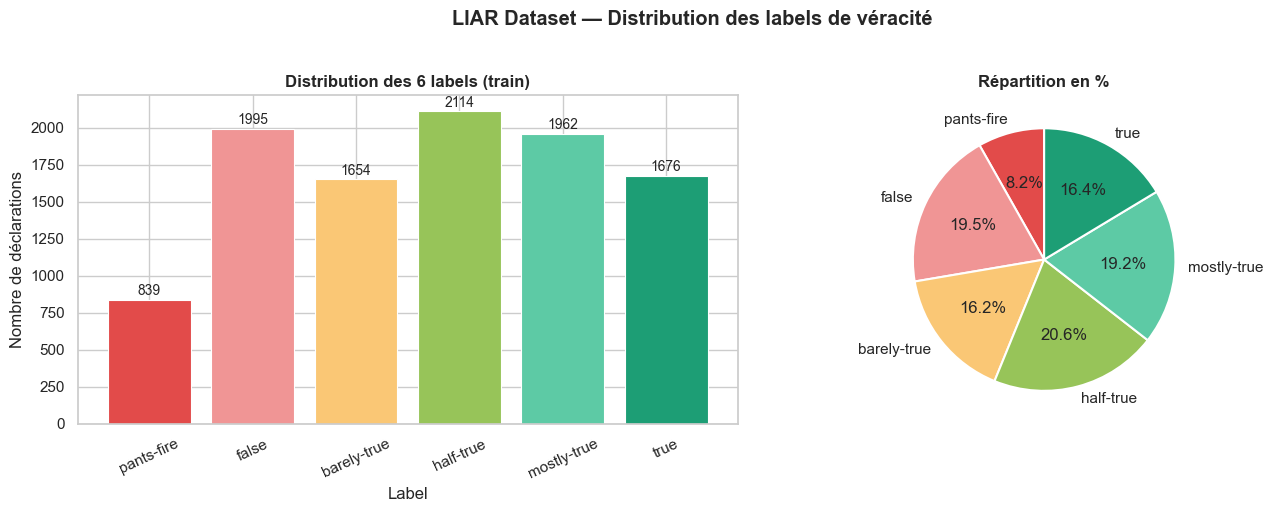


 Doc/EDA_01_distribution_labels.png


In [5]:
counts = train_df['label'].value_counts().reindex(LABEL_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(counts.index, counts.values, color=LABEL_COLORS, edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribution des 6 labels (train)', fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Nombre de déclarations')
axes[0].tick_params(axis='x', rotation=25)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=10)

axes[1].pie(counts.values, labels=counts.index, colors=LABEL_COLORS,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Répartition en %', fontweight='bold')

plt.suptitle('LIAR Dataset — Distribution des labels de véracité', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../Doc/EDA_01_distribution_labels.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n Doc/EDA_01_distribution_labels.png')

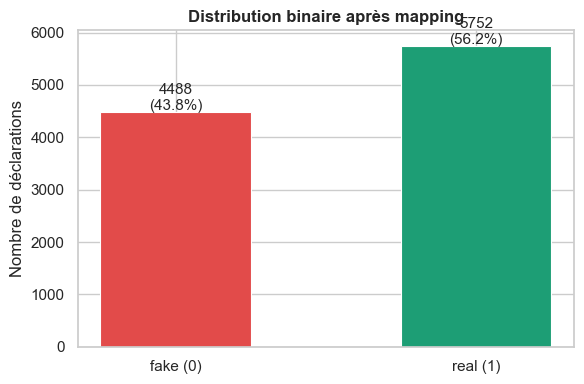

In [6]:
# Distribution binaire (après mapping)
binary_counts = train_df['label'].map(LABEL_MAP).value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['fake (0)', 'real (1)'], binary_counts.reindex([0,1]).values,
       color=['#E24B4A','#1D9E75'], edgecolor='white', linewidth=0.8, width=0.5)
ax.set_title('Distribution binaire après mapping', fontweight='bold')
ax.set_ylabel('Nombre de déclarations')
for i, v in enumerate(binary_counts.reindex([0,1]).values):
    ax.text(i, v + 30, f'{v}\n({v/len(train_df)*100:.1f}%)', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('../Doc/EDA_02_distribution_binaire.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Analyse des speakers et partis politiques

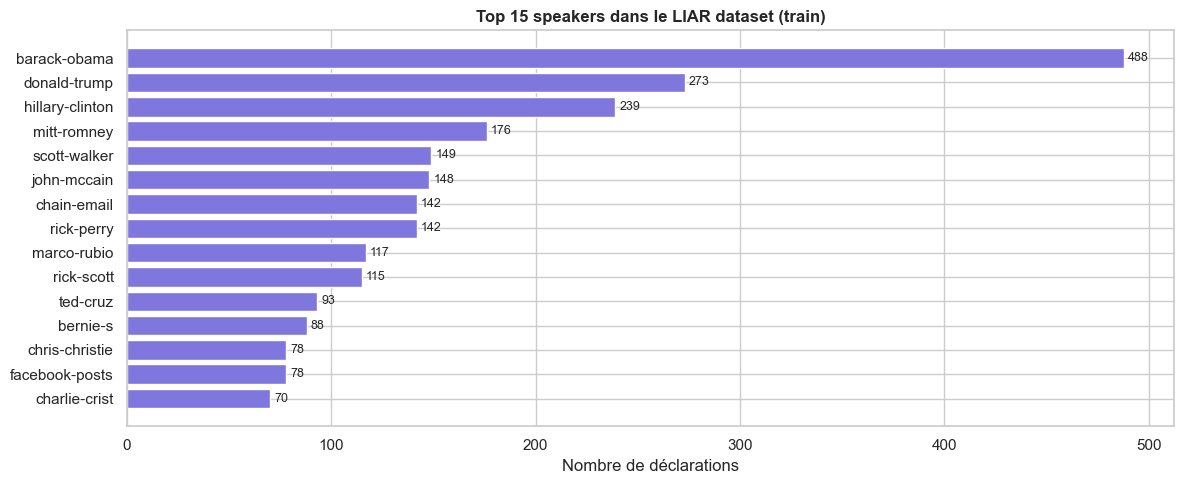

In [7]:
# Top 15 speakers
top_speakers = train_df['speaker'].value_counts().head(15)

plt.figure(figsize=(12, 5))
bars = plt.barh(top_speakers.index[::-1], top_speakers.values[::-1],
                color='#7F77DD', edgecolor='white')
plt.title('Top 15 speakers dans le LIAR dataset (train)', fontweight='bold')
plt.xlabel('Nombre de déclarations')
for bar, val in zip(bars, top_speakers.values[::-1]):
    plt.text(val + 2, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../Doc/EDA_03_top_speakers.png', dpi=150, bbox_inches='tight')
plt.show()

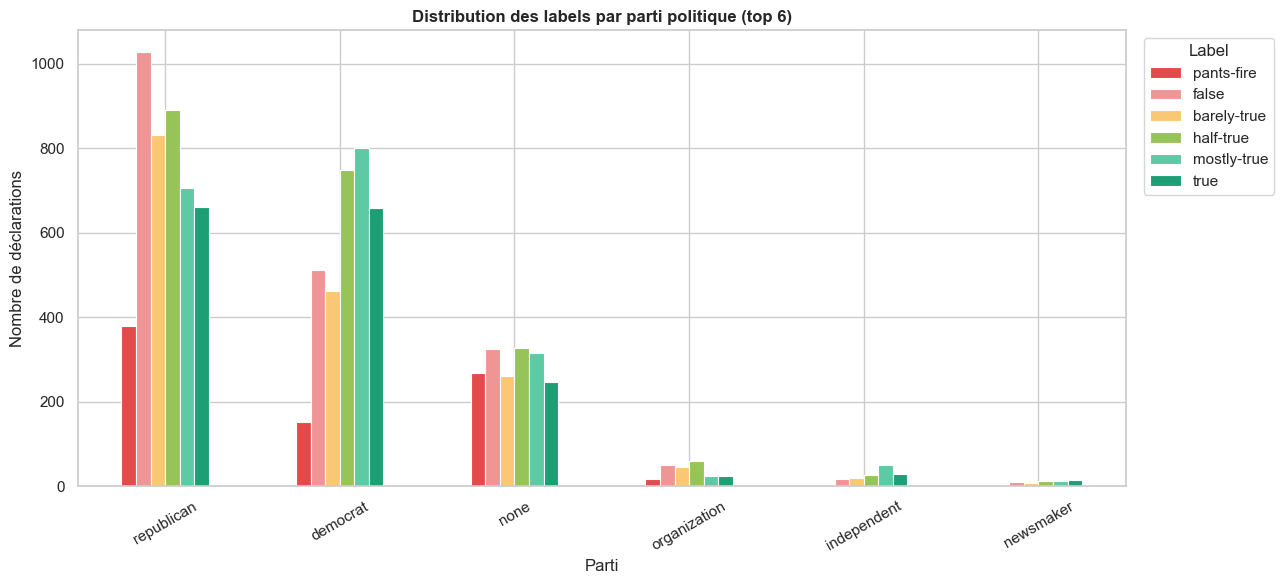

In [8]:
# Labels par parti politique
top_parties = train_df['party'].value_counts().head(6).index
party_label = (
    train_df.groupby(['party','label']).size()
    .unstack(fill_value=0)
    .loc[top_parties, LABEL_ORDER]
)
party_label.plot(kind='bar', figsize=(13, 6), color=LABEL_COLORS,
                 edgecolor='white', linewidth=0.8)
plt.title('Distribution des labels par parti politique (top 6)', fontweight='bold')
plt.xlabel('Parti')
plt.ylabel('Nombre de déclarations')
plt.legend(title='Label', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../Doc/EDA_04_labels_by_party.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Analyse de la longueur des déclarations

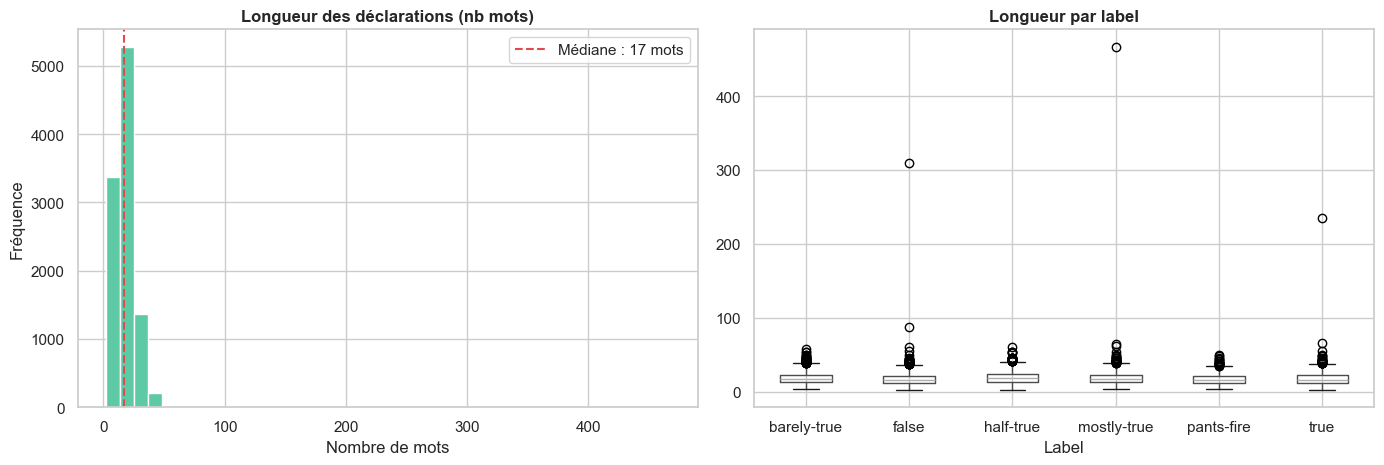

Longueur moyenne  : 18.0 mots
Longueur médiane  : 17 mots
Longueur max      : 467 mots


In [9]:
train_df['text_length'] = train_df['statement'].fillna('').apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df['text_length'], bins=40, color='#5DCAA5', edgecolor='white')
axes[0].axvline(train_df['text_length'].median(), color='#E24B4A', linestyle='--',
                label=f'Médiane : {train_df["text_length"].median():.0f} mots')
axes[0].set_title('Longueur des déclarations (nb mots)', fontweight='bold')
axes[0].set_xlabel('Nombre de mots')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

train_df.boxplot(column='text_length', by='label', ax=axes[1])
axes[1].set_title('Longueur par label', fontweight='bold')
axes[1].set_xlabel('Label')
plt.suptitle('')
plt.tight_layout()
plt.savefig('../Doc/EDA_05_text_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Longueur moyenne  : {train_df["text_length"].mean():.1f} mots')
print(f'Longueur médiane  : {train_df["text_length"].median():.0f} mots')
print(f'Longueur max      : {train_df["text_length"].max()} mots')

## 5. Sauvegarde des features EDA

In [10]:
# Sauvegarde du dataset EDA enrichi (avec text_length, binary_label)
liar_eda = liar_unifie.copy()
liar_eda['text_length'] = liar_eda['statement'].fillna('').apply(lambda x: len(x.split()))

liar_eda.to_parquet('../data/traitees/liar_eda_features.parquet', index=False)
print(' data/traitees/liar_eda_features.parquet')

# Résumé statistique
print('\n Résumé du dataset :')
print(f'  Total déclarations : {len(liar_eda):,}')
print(f'  Speakers uniques   : {liar_eda["speaker"].nunique():,}')
print(f'  Partis uniques     : {liar_eda["party"].nunique():,}')
print(f'  Sujets uniques     : {liar_eda["subject"].nunique():,}')
print(f'  Valeurs manquantes :')
print(liar_eda[['statement','speaker','party','subject']].isnull().sum().to_string())
print('\n EDA terminée → lancer Modeles_de_Base.ipynb')

 data/traitees/liar_eda_features.parquet

 Résumé du dataset :
  Total déclarations : 12,791
  Speakers uniques   : 3,309
  Partis uniques     : 24
  Sujets uniques     : 4,534
  Valeurs manquantes :
statement    0
speaker      2
party        2
subject      2

 EDA terminée → lancer Modeles_de_Base.ipynb
